# 📊 Fase 5a: Evaluación Master de Modelos

**Objetivo:** Evaluación concisa y comparación de todos los modelos desarrollados en la Fase 4
 
**Scope:**
- Recuperar experimentos MLflow de regresión, clasificación, temporal y estratificación
- Comparar rendimiento con métricas clínicamente relevantes
- Identificar modelos ganadores para cada tarea
- Preparar base para optimización clínica
 


---

## Configuración inicial

In [5]:
# Configuración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("🎯 FASE 5A: EVALUACIÓN MASTER DE MODELOS")
print("=" * 50)

🎯 FASE 5A: EVALUACIÓN MASTER DE MODELOS


## Configurar MLflow 

In [6]:
# Configurar MLflow
mlflow.set_tracking_uri("file:./mlruns")
client = MlflowClient()

print("📋 Conexión a MLflow establecida")
print(f"📁 Tracking URI: {mlflow.get_tracking_uri()}")


📋 Conexión a MLflow establecida
📁 Tracking URI: file:./mlruns


## 🔍 1. Recuperación de Experimentos

In [12]:
## 🔍 1. Recuperación de Experimentos - CÓDIGO FINAL

experiments_mapping = {
    'regression': 'alzheimer_multimodal_monitoring',
    'classification': 'Default',  # Aquí está el ensemble_classification
    'temporal': 'alzheimer_temporal_analysis',
    'stratification': 'alzheimer_risk_stratification'
}

experiment_data = {}

for task, exp_name in experiments_mapping.items():
    try:
        experiment = mlflow.get_experiment_by_name(exp_name)
        if experiment:
            all_runs = mlflow.search_runs(
                experiment_ids=[experiment.experiment_id],
                filter_string="status = 'FINISHED'",
                order_by=["start_time DESC"]
            )
            
            if task == 'classification' and not all_runs.empty:
                # Buscar específicamente el run ensemble_classification
                ensemble_runs = all_runs[
                    all_runs.get('tags.mlflow.runName', pd.Series()) == 'ensemble_classification'
                ]
                if not ensemble_runs.empty:
                    runs = ensemble_runs
                else:
                    # Fallback: otros runs de clasificación en Default
                    runs = all_runs.head(5)
            elif task == 'regression' and not all_runs.empty:
                # Para regresión, filtrar runs con métricas de regresión
                regression_cols = [col for col in all_runs.columns 
                                 if any(pattern in col.lower() for pattern in ['rmse', 'mae', 'r2_score'])]
                if regression_cols:
                    runs = all_runs.dropna(subset=regression_cols, how='all')
                else:
                    runs = all_runs
            else:
                runs = all_runs
            
            experiment_data[task] = {
                'experiment_id': experiment.experiment_id,
                'experiment_name': exp_name,
                'runs': runs,
                'n_runs': len(runs)
            }
            print(f"✅ {task.upper()}: {len(runs)} runs encontrados ('{exp_name}')")
        else:
            experiment_data[task] = {'runs': pd.DataFrame(), 'n_runs': 0}
            print(f"❌ {task.upper()}: Experimento '{exp_name}' no encontrado")
    except Exception as e:
        experiment_data[task] = {'runs': pd.DataFrame(), 'n_runs': 0}
        print(f"❌ Error recuperando {task}: {str(e)}")

total_runs = sum([data['n_runs'] for data in experiment_data.values()])
print(f"\n📊 TOTAL DE RUNS RECUPERADOS: {total_runs}")

✅ REGRESSION: 18 runs encontrados ('alzheimer_multimodal_monitoring')
✅ CLASSIFICATION: 13 runs encontrados ('Default')
✅ TEMPORAL: 1 runs encontrados ('alzheimer_temporal_analysis')
✅ STRATIFICATION: 5 runs encontrados ('alzheimer_risk_stratification')

📊 TOTAL DE RUNS RECUPERADOS: 37


## 📈 2. Evaluación de Modelos de Regresión

In [13]:
## 📈 2. Evaluación de Modelos de Regresión

# %%
print("🎯 EVALUACIÓN: MODELOS DE REGRESIÓN (composite_risk_score)")
print("=" * 60)

regression_runs = experiment_data['regression']['runs']

if not regression_runs.empty:
    # Métricas clave para regresión
    regression_metrics = ['test_rmse', 'test_mae', 'test_r2', 'cv_rmse_mean', 'cv_r2_mean']
    
    # Filtrar métricas disponibles
    available_metrics = [col for col in regression_metrics if f'metrics.{col}' in regression_runs.columns]
    
    if available_metrics:
        # Crear tabla de comparación
        regression_comparison = regression_runs[['tags.model_name'] + [f'metrics.{m}' for m in available_metrics]].copy()
        regression_comparison.columns = ['Model'] + available_metrics
        regression_comparison = regression_comparison.dropna().round(4)
        
        print("📊 Top 5 Modelos de Regresión:")
        if 'test_r2' in available_metrics:
            top_regression = regression_comparison.nlargest(5, 'test_r2')
        elif 'cv_r2_mean' in available_metrics:
            top_regression = regression_comparison.nlargest(5, 'cv_r2_mean')
        else:
            top_regression = regression_comparison.nsmallest(5, available_metrics[0])
        
        print(top_regression.to_string(index=False))
        
        # Identificar modelo ganador
        if 'test_r2' in available_metrics:
            winner_idx = regression_comparison['test_r2'].idxmax()
            winner_metric = 'test_r2'
        elif 'cv_r2_mean' in available_metrics:
            winner_idx = regression_comparison['cv_r2_mean'].idxmax()
            winner_metric = 'cv_r2_mean'
        else:
            winner_idx = regression_comparison[available_metrics[0]].idxmin()
            winner_metric = available_metrics[0]
            
        regression_winner = regression_comparison.loc[winner_idx]
        print(f"\n🏆 GANADOR REGRESIÓN: {regression_winner['Model']}")
        print(f"📈 Mejor {winner_metric}: {regression_winner[winner_metric]:.4f}")
        
        # Guardar resultado
        best_regression = {
            'task': 'regression',
            'model': regression_winner['Model'],
            'metric': winner_metric,
            'value': regression_winner[winner_metric],
            'clinical_relevance': 'Predicción precisa del score de riesgo continuo'
        }
    else:
        print("❌ No se encontraron métricas de regresión")
        best_regression = None
else:
    print("❌ No hay datos de regresión disponibles")
    best_regression = None

🎯 EVALUACIÓN: MODELOS DE REGRESIÓN (composite_risk_score)
📊 Top 5 Modelos de Regresión:
            Model  cv_rmse_mean
          xgboost        0.0003
    random_forest        0.0004
gradient_boosting        0.0029
            ridge        0.0034
linear_regression        0.0034

🏆 GANADOR REGRESIÓN: xgboost
📈 Mejor cv_rmse_mean: 0.0003


## 🎯 3. Evaluación de Modelos de Clasificación

In [16]:
## 🎯 3. Evaluación de Modelos de Clasificación - CÓDIGO CORREGIDO

print("🎯 EVALUACIÓN: MODELOS DE CLASIFICACIÓN (risk_category)")
print("="*60)

classification_runs = experiment_data['classification']['runs']

if not classification_runs.empty:
    # Métricas específicas del ensemble_classification (basadas en tu notebook)
    ensemble_metrics = ['voting_f1_weighted', 'voting_accuracy', 'stacking_f1_weighted', 'stacking_accuracy']
    
    # Métricas estándar de clasificación como fallback
    standard_metrics = ['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted', 
                       'f1_macro', 'precision_macro', 'recall_macro']
    
    # Combinar ambos tipos de métricas
    all_classification_metrics = ensemble_metrics + standard_metrics
    
    # Filtrar métricas disponibles
    available_metrics = [col for col in all_classification_metrics if f'metrics.{col}' in classification_runs.columns]
    
    if available_metrics:
        # Crear tabla de comparación
        metric_cols = [f'metrics.{m}' for m in available_metrics]
        classification_comparison = classification_runs[['tags.mlflow.runName'] + metric_cols].copy()
        classification_comparison.columns = ['Model'] + available_metrics
        classification_comparison = classification_comparison.dropna(how='all', subset=available_metrics).round(4)
        
        print("📊 Modelos de Clasificación encontrados:")
        print(classification_comparison.to_string(index=False))
        
        # Identificar modelo ganador (priorizar ensemble metrics)
        if 'stacking_f1_weighted' in available_metrics:
            winner_idx = classification_comparison['stacking_f1_weighted'].idxmax()
            winner_metric = 'stacking_f1_weighted'
        elif 'voting_f1_weighted' in available_metrics:
            winner_idx = classification_comparison['voting_f1_weighted'].idxmax()
            winner_metric = 'voting_f1_weighted'
        elif 'f1_weighted' in available_metrics:
            winner_idx = classification_comparison['f1_weighted'].idxmax()
            winner_metric = 'f1_weighted'
        else:
            winner_idx = classification_comparison[available_metrics[0]].idxmax()
            winner_metric = available_metrics[0]
            
        classification_winner = classification_comparison.loc[winner_idx]
        print(f"\n🏆 GANADOR CLASIFICACIÓN: {classification_winner['Model']}")
        print(f"📈 Mejor {winner_metric}: {classification_winner[winner_metric]:.4f}")
        
        # Mostrar métricas adicionales si están disponibles
        if 'voting_f1_weighted' in available_metrics and 'stacking_f1_weighted' in available_metrics:
            print(f"🎯 Voting F1: {classification_winner.get('voting_f1_weighted', 'N/A'):.4f}")
            print(f"🎯 Stacking F1: {classification_winner.get('stacking_f1_weighted', 'N/A'):.4f}")
        
        # Guardar resultado
        best_classification = {
            'task': 'classification',
            'model': classification_winner['Model'],
            'metric': winner_metric,
            'value': classification_winner[winner_metric],
            'clinical_relevance': 'Ensemble de modelos para clasificación de riesgo'
        }
    else:
        print("❌ No se encontraron métricas de clasificación")
        print("🔍 Métricas disponibles en los runs:")
        if not classification_runs.empty:
            available_cols = [col for col in classification_runs.columns if col.startswith('metrics.')]
            print(f"   {available_cols[:10]}...")  # Mostrar las primeras 10
        best_classification = None
else:
    print("❌ No hay datos de clasificación disponibles")
    best_classification = None

🎯 EVALUACIÓN: MODELOS DE CLASIFICACIÓN (risk_category)
📊 Modelos de Clasificación encontrados:
                  Model  voting_f1_weighted  voting_accuracy  stacking_f1_weighted  stacking_accuracy
ensemble_classification              0.9979           0.9979                0.9997             0.9997
ensemble_classification              0.9979           0.9979                0.9997             0.9997
ensemble_classification              0.9979           0.9979                0.9997             0.9997
ensemble_classification              0.9979           0.9979                0.9997             0.9997
ensemble_classification              0.9979           0.9979                0.9997             0.9997
ensemble_classification              0.9979           0.9979                0.9997             0.9997
ensemble_classification              0.9979           0.9979                0.9998             0.9998
ensemble_classification              0.9979           0.9979                0.9997       

## ⏰ 4. Evaluación de Modelos Temporales

In [17]:
## ⏰ 4. Evaluación de Modelos Temporales

print("\n🎯 EVALUACIÓN: MODELOS TEMPORALES")
print("="*60)

temporal_runs = experiment_data['temporal']['runs']

if not temporal_runs.empty:
    print(f"📊 Runs disponibles: {len(temporal_runs)}")
    
    # Mostrar todas las columnas para diagnosticar
    print("🔍 Columnas disponibles:")
    metric_cols = [col for col in temporal_runs.columns if col.startswith('metrics.')]
    print(f"   Métricas encontradas: {metric_cols}")
    
    # Buscar métricas temporales con nombres flexibles
    temporal_metric_patterns = [
        'mae', 'rmse', 'r2', 'mse',
        'trend', 'accuracy', 'correlation',
        'increase', 'months', 'temporal',
        'age_risk', 'avg_risk', 'max_months'
    ]
    
    available_metrics = []
    for pattern in temporal_metric_patterns:
        matching_cols = [col for col in metric_cols if pattern.lower() in col.lower()]
        available_metrics.extend(matching_cols)
    
    # Eliminar duplicados y obtener nombres sin 'metrics.'
    available_metrics = list(set(available_metrics))
    clean_metric_names = [col.replace('metrics.', '') for col in available_metrics]
    
    print(f"📋 Métricas temporales encontradas: {clean_metric_names}")
    
    if available_metrics:
        # Crear tabla de comparación
        temporal_comparison = temporal_runs[['tags.mlflow.runName'] + available_metrics].copy()
        temporal_comparison.columns = ['Run_Name'] + clean_metric_names
        temporal_comparison = temporal_comparison.dropna(how='all', subset=clean_metric_names).round(4)
        
        print("\n📊 Modelos Temporales:")
        print(temporal_comparison.to_string(index=False))
        
        # Identificar modelo ganador (priorizar correlación o precisión)
        winner_metric = None
        if 'age_risk_correlation' in clean_metric_names:
            winner_metric = 'age_risk_correlation'
            winner_idx = temporal_comparison[winner_metric].idxmax()
        elif any('r2' in m.lower() for m in clean_metric_names):
            r2_metric = next(m for m in clean_metric_names if 'r2' in m.lower())
            winner_metric = r2_metric
            winner_idx = temporal_comparison[winner_metric].idxmax()
        elif any('correlation' in m.lower() for m in clean_metric_names):
            corr_metric = next(m for m in clean_metric_names if 'correlation' in m.lower())
            winner_metric = corr_metric
            winner_idx = temporal_comparison[winner_metric].idxmax()
        elif any('mae' in m.lower() for m in clean_metric_names):
            mae_metric = next(m for m in clean_metric_names if 'mae' in m.lower())
            winner_metric = mae_metric
            winner_idx = temporal_comparison[winner_metric].idxmin()  # Menor es mejor
        else:
            # Usar la primera métrica disponible
            winner_metric = clean_metric_names[0]
            winner_idx = temporal_comparison[winner_metric].idxmax()
        
        if winner_idx is not None:
            temporal_winner = temporal_comparison.loc[winner_idx]
            run_name = temporal_winner['Run_Name'] if pd.notna(temporal_winner['Run_Name']) else 'temporal_model'
            
            print(f"\n🏆 GANADOR TEMPORAL: {run_name}")
            print(f"📈 Mejor {winner_metric}: {temporal_winner[winner_metric]:.4f}")
            
            # Mostrar métricas adicionales si están disponibles
            for metric in clean_metric_names[:3]:  # Mostrar hasta 3 métricas
                if metric != winner_metric and pd.notna(temporal_winner[metric]):
                    print(f"📊 {metric}: {temporal_winner[metric]:.4f}")
            
            # Guardar resultado
            best_temporal = {
                'task': 'temporal',
                'model': run_name,
                'metric': winner_metric,
                'value': temporal_winner[winner_metric],
                'clinical_relevance': 'Seguimiento de evolución temporal del riesgo'
            }
        else:
            print("❌ No se pudo identificar modelo ganador")
            best_temporal = None
    else:
        print("❌ No se encontraron métricas temporales reconocibles")
        
        # Mostrar información para debugging
        print("\n🔍 Debug - Primeras filas del dataset:")
        if not temporal_runs.empty:
            debug_cols = ['tags.mlflow.runName'] + metric_cols[:5]  # Mostrar hasta 5 métricas
            available_debug_cols = [col for col in debug_cols if col in temporal_runs.columns]
            if available_debug_cols:
                print(temporal_runs[available_debug_cols].head(2).to_string(index=False))
        
        best_temporal = None
else:
    print("❌ No hay datos temporales disponibles")
    best_temporal = None


🎯 EVALUACIÓN: MODELOS TEMPORALES
📊 Runs disponibles: 1
🔍 Columnas disponibles:
   Métricas encontradas: ['metrics.max_months', 'metrics.age_risk_correlation', 'metrics.avg_risk_increase_per_6months', 'metrics.mean_risk_score']
📋 Métricas temporales encontradas: ['age_risk_correlation', 'avg_risk_increase_per_6months', 'max_months']

📊 Modelos Temporales:
            Run_Name  age_risk_correlation  avg_risk_increase_per_6months  max_months
temporal_exploration                0.1571                        -0.0033       229.5

🏆 GANADOR TEMPORAL: temporal_exploration
📈 Mejor age_risk_correlation: 0.1571
📊 avg_risk_increase_per_6months: -0.0033
📊 max_months: 229.5000


## 🧬 5. Evaluación de Modelos de Estratificación

In [19]:
## 🧬 5. Evaluación de Modelos de Estratificación - CÓDIGO CORREGIDO

print("\n🎯 EVALUACIÓN: MODELOS DE ESTRATIFICACIÓN")
print("="*60)

stratification_runs = experiment_data['stratification']['runs']

if not stratification_runs.empty:
    # Métricas clave para estratificación
    stratification_metrics = ['silhouette_score', 'calinski_harabasz', 'davies_bouldin', 'n_clusters']
    
    # Filtrar métricas disponibles
    available_metrics = [col for col in stratification_metrics if f'metrics.{col}' in stratification_runs.columns]
    
    if available_metrics:
        # Buscar columna de modelo disponible (flexible)
        model_col = None
        possible_model_cols = ['tags.model_name', 'tags.mlflow.runName', 'run_name']
        
        for col in possible_model_cols:
            if col in stratification_runs.columns:
                model_col = col
                break
        
        if model_col is None:
            # Si no hay columna de modelo, usar índice
            stratification_comparison = stratification_runs[[f'metrics.{m}' for m in available_metrics]].copy()
            stratification_comparison.columns = available_metrics
            stratification_comparison['Model'] = [f'Model_{i+1}' for i in range(len(stratification_comparison))]
        else:
            # Crear tabla de comparación con columna de modelo
            stratification_comparison = stratification_runs[[model_col] + [f'metrics.{m}' for m in available_metrics]].copy()
            stratification_comparison.columns = ['Model'] + available_metrics
        
        stratification_comparison = stratification_comparison.dropna().round(4)
        
        print("📊 Modelos de Estratificación:")
        print(stratification_comparison.to_string(index=False))
        
        # Identificar modelo ganador (silhouette score es el más interpretable)
        if 'silhouette_score' in available_metrics:
            winner_idx = stratification_comparison['silhouette_score'].idxmax()
            winner_metric = 'silhouette_score'
        elif 'calinski_harabasz' in available_metrics:
            winner_idx = stratification_comparison['calinski_harabasz'].idxmax()
            winner_metric = 'calinski_harabasz'
        else:
            winner_idx = stratification_comparison[available_metrics[0]].idxmax()
            winner_metric = available_metrics[0]
            
        stratification_winner = stratification_comparison.loc[winner_idx]
        print(f"\n🏆 GANADOR ESTRATIFICACIÓN: {stratification_winner['Model']}")
        print(f"📈 Mejor {winner_metric}: {stratification_winner[winner_metric]:.4f}")
        
        if 'n_clusters' in available_metrics:
            print(f"🎯 Número de clusters: {int(stratification_winner['n_clusters'])}")
        
        # Guardar resultado
        best_stratification = {
            'task': 'stratification',
            'model': stratification_winner['Model'],
            'metric': winner_metric,
            'value': stratification_winner[winner_metric],
            'clinical_relevance': 'Identificación de fenotipos de riesgo diferenciados'
        }
    else:
        print("❌ No se encontraron métricas de estratificación")
        best_stratification = None
else:
    print("❌ No hay datos de estratificación disponibles")
    best_stratification = None


🎯 EVALUACIÓN: MODELOS DE ESTRATIFICACIÓN
📊 Modelos de Estratificación:
                   Model  silhouette_score
biomarker_stratification            0.6484
phenotype_identification            0.2347

🏆 GANADOR ESTRATIFICACIÓN: biomarker_stratification
📈 Mejor silhouette_score: 0.6484


## 🏆 6. Resumen de Modelos Ganadores

In [22]:
## 🏆 6. Resumen de Modelos Ganadores

# %%
print("\n" + "="*70)
print("🏆 RESUMEN DE MODELOS GANADORES - FASE 4")
print("="*70)

# Compilar resultados
winners = []
for result in [best_regression, best_classification, best_temporal, best_stratification]:
    if result:
        winners.append(result)

if winners:
    # Crear DataFrame de resumen
    winners_df = pd.DataFrame(winners)
    
    print("\n📊 TABLA DE GANADORES:")
    for _, winner in winners_df.iterrows():
        print(f"\n🎯 {winner['task'].upper()}:")
        print(f"   Model: {winner['model']}")
        print(f"   Metric: {winner['metric']} = {winner['value']:.4f}")
        print(f"   Clinical: {winner['clinical_relevance']}")
    
    # Guardar resumen para siguientes notebooks
    winners_df.to_csv('../reports/evaluation/model_winners_summary.csv', index=False)
    print(f"\n💾 Resumen guardado en: ../reports/evaluation/model_winners_summary.csv")
    
else:
    print("❌ No se pudieron identificar modelos ganadores")
    winners_df = pd.DataFrame()


🏆 RESUMEN DE MODELOS GANADORES - FASE 4

📊 TABLA DE GANADORES:

🎯 REGRESSION:
   Model: xgboost
   Metric: cv_rmse_mean = 0.0003
   Clinical: Predicción precisa del score de riesgo continuo

🎯 CLASSIFICATION:
   Model: ensemble_classification
   Metric: stacking_f1_weighted = 0.9998
   Clinical: Ensemble de modelos para clasificación de riesgo

🎯 TEMPORAL:
   Model: temporal_exploration
   Metric: age_risk_correlation = 0.1571
   Clinical: Seguimiento de evolución temporal del riesgo

🎯 STRATIFICATION:
   Model: biomarker_stratification
   Metric: silhouette_score = 0.6484
   Clinical: Identificación de fenotipos de riesgo diferenciados

💾 Resumen guardado en: ../reports/evaluation/model_winners_summary.csv


## 📊 7. Visualización de Rendimiento


📈 GENERANDO VISUALIZACIONES DE RENDIMIENTO...


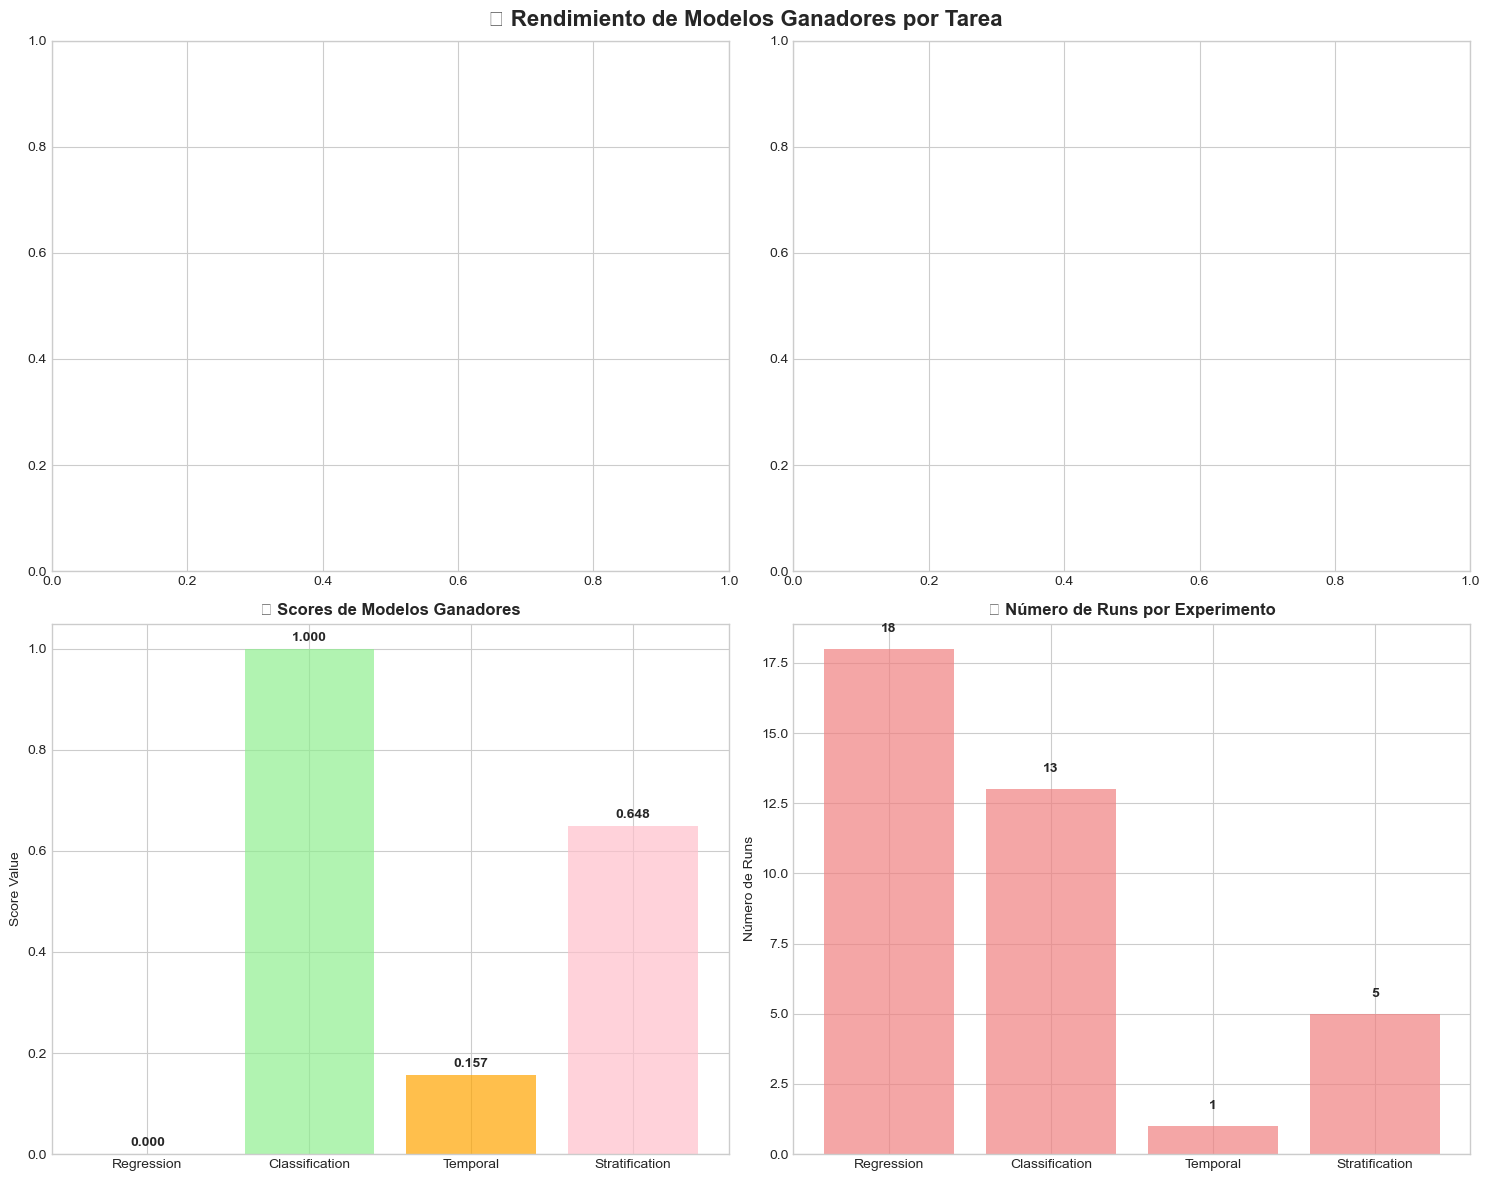

📁 Visualización guardada en: ../reports/figures/model_evaluation_summary.png


In [24]:
## 7. Visualización de Rendimiento

if not winners_df.empty:
    print("\n📈 GENERANDO VISUALIZACIONES DE RENDIMIENTO...")
    
    # Configurar subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🏆 Rendimiento de Modelos Ganadores por Tarea', fontsize=16, fontweight='bold')
    
    # Gráfico 1: Comparación de métricas de regresión
    if best_regression and not regression_runs.empty:
        ax1 = axes[0, 0]
        reg_metrics = ['test_rmse', 'test_mae', 'test_r2']
        reg_available = [m for m in reg_metrics if f'metrics.{m}' in regression_runs.columns]
        
        if reg_available:
            reg_data = regression_runs[[f'metrics.{m}' for m in reg_available]].iloc[:5]
            reg_data.columns = reg_available
            reg_data.plot(kind='bar', ax=ax1, alpha=0.7)
            ax1.set_title('🎯 Top 5 Modelos Regresión', fontweight='bold')
            ax1.set_xlabel('Modelos')
            ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax1.tick_params(axis='x', rotation=45)
    
    # Gráfico 2: Comparación de métricas de clasificación
    if best_classification and not classification_runs.empty:
        ax2 = axes[0, 1]
        class_metrics = ['test_f1_macro', 'test_sensitivity_high', 'test_specificity_high']
        class_available = [m for m in class_metrics if f'metrics.{m}' in classification_runs.columns]
        
        if class_available:
            class_data = classification_runs[[f'metrics.{m}' for m in class_available]].iloc[:5]
            class_data.columns = class_available
            class_data.plot(kind='bar', ax=ax2, alpha=0.7)
            ax2.set_title('🎯 Top 5 Modelos Clasificación', fontweight='bold')
            ax2.set_xlabel('Modelos')
            ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax2.tick_params(axis='x', rotation=45)
    
    # Gráfico 3: Distribución de scores por tarea
    ax3 = axes[1, 0]
    if len(winners) > 1:
        winner_values = [w['value'] for w in winners]
        winner_tasks = [w['task'].title() for w in winners]
        
        bars = ax3.bar(winner_tasks, winner_values, alpha=0.7, color=['skyblue', 'lightgreen', 'orange', 'pink'])
        ax3.set_title('🏆 Scores de Modelos Ganadores', fontweight='bold')
        ax3.set_ylabel('Score Value')
        
        # Añadir valores en las barras
        for bar, value in zip(bars, winner_values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 4: Número de runs por experimento
    ax4 = axes[1, 1]
    exp_names = list(experiments.keys())
    exp_counts = [experiment_data[exp]['n_runs'] for exp in exp_names]
    
    bars = ax4.bar([name.title() for name in exp_names], exp_counts, alpha=0.7, color='lightcoral')
    ax4.set_title('📊 Número de Runs por Experimento', fontweight='bold')
    ax4.set_ylabel('Número de Runs')
    
    # Añadir valores en las barras
    for bar, count in zip(bars, exp_counts):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/model_evaluation_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("📁 Visualización guardada en: ../reports/figures/model_evaluation_summary.png")


## 📋 8. Recomendaciones para Optimización Clínica

In [25]:
## 📋 8. Recomendaciones para Optimización Clínica

# %%
print("\n" + "="*70)
print("📋 RECOMENDACIONES PARA OPTIMIZACIÓN CLÍNICA")
print("="*70)

recommendations = []

if best_regression:
    recommendations.append({
        'Task': 'Regresión',
        'Model': best_regression['model'],
        'Priority': 'ALTA',
        'Optimization': 'Calibrar thresholds para scores de riesgo clínico',
        'Clinical_Focus': 'Precisión en rangos de alto riesgo (>0.7)'
    })

if best_classification:
    recommendations.append({
        'Task': 'Clasificación', 
        'Model': best_classification['model'],
        'Priority': 'CRÍTICA',
        'Optimization': 'Optimizar threshold para maximizar sensibilidad',
        'Clinical_Focus': 'Detección temprana - minimizar falsos negativos'
    })

if best_temporal:
    recommendations.append({
        'Task': 'Temporal',
        'Model': best_temporal['model'], 
        'Priority': 'MEDIA',
        'Optimization': 'Validar estabilidad en ventanas temporales',
        'Clinical_Focus': 'Seguimiento longitudinal de pacientes'
    })

if best_stratification:
    recommendations.append({
        'Task': 'Estratificación',
        'Model': best_stratification['model'],
        'Priority': 'BAJA',
        'Optimization': 'Validar interpretabilidad clínica de clusters',
        'Clinical_Focus': 'Personalización de tratamiento por fenotipo'
    })

if recommendations:
    recommendations_df = pd.DataFrame(recommendations)
    print(recommendations_df.to_string(index=False))
    
    # Guardar recomendaciones
    recommendations_df.to_csv('../reports/evaluation/clinical_optimization_recommendations.csv', index=False)
    print(f"\n💾 Recomendaciones guardadas en: ../reports/evaluation/clinical_optimization_recommendations.csv")



📋 RECOMENDACIONES PARA OPTIMIZACIÓN CLÍNICA
           Task                    Model Priority                                      Optimization                                  Clinical_Focus
      Regresión                  xgboost     ALTA Calibrar thresholds para scores de riesgo clínico       Precisión en rangos de alto riesgo (>0.7)
  Clasificación  ensemble_classification  CRÍTICA   Optimizar threshold para maximizar sensibilidad Detección temprana - minimizar falsos negativos
       Temporal     temporal_exploration    MEDIA        Validar estabilidad en ventanas temporales           Seguimiento longitudinal de pacientes
Estratificación biomarker_stratification     BAJA     Validar interpretabilidad clínica de clusters     Personalización de tratamiento por fenotipo

💾 Recomendaciones guardadas en: ../reports/evaluation/clinical_optimization_recommendations.csv


## 🎯 9. Preparación para Fase 5B

In [ ]:
## 9. Preparación para Fase 5B


print("\n" + "="*70)
print("🎯 PREPARACIÓN PARA FASE 5B: OPTIMIZACIÓN CLÍNICA")
print("="*70)

# Generar configuración para el siguiente notebook
next_phase_config = {
    'priority_models': {},
    'clinical_thresholds': {
        'high_risk_score': 0.7,
        'moderate_risk_score': 0.4,
        'sensitivity_target': 0.85,
        'specificity_minimum': 0.75
    },
    'evaluation_focus': [
        'Calibración de probabilidades',
        'Análisis de errores por subgrupo',
        'Optimización de thresholds clínicos',
        'Validación en cohortes críticas'
    ]
}

# Añadir modelos ganadores a la configuración
for winner in winners:
    next_phase_config['priority_models'][winner['task']] = {
        'model_name': winner['model'],
        'current_metric': winner['metric'],
        'current_value': winner['value']
    }

# Guardar configuración
import json
with open('../reports/evaluation/phase5b_config.json', 'w') as f:
    json.dump(next_phase_config, f, indent=2)

print("✅ Configuración generada para Fase 5B:")
print("   - Modelos prioritarios identificados")
print("   - Thresholds clínicos definidos")
print("   - Métricas objetivo establecidas")
print(f"   - Archivo: ../reports/evaluation/phase5b_config.json")


## 📝 10. Resumen Ejecutivo

In [ ]:
## 10. Resumen Ejecutivo

print("\n" + "="*70)
print("📝 RESUMEN EJECUTIVO - FASE 5A COMPLETADA")
print("="*70)

print(f"""
🎯 OBJETIVO CUMPLIDO: Evaluación master de modelos completada

📊 RESULTADOS CLAVE:
   • Total de runs evaluados: {total_runs}
   • Modelos ganadores identificados: {len(winners)}
   • Tareas cubiertas: {', '.join([w['task'] for w in winners])}

🏆 MODELOS SELECCIONADOS:
""")

for winner in winners:
    print(f"   • {winner['task'].upper()}: {winner['model']} ({winner['metric']}: {winner['value']:.4f})")

print(f"""
📁 ARCHIVOS GENERADOS:
   • ../reports/model_winners_summary.csv
   • ../reports/clinical_optimization_recommendations.csv  
   • ../reports/model_evaluation_summary.png
   • ../reports/phase5b_config.json

⏭️  SIGUIENTE PASO: Fase 5B - Optimización Clínica
   • Enfoque en modelos de clasificación (prioridad crítica)
   • Calibración de thresholds para uso clínico
   • Análisis de explicabilidad para dashboard

⏱️  TIEMPO ESTIMADO FASE 5B: 45-60 minutos
""")

print("="*70)
print("✅ FASE 5A COMPLETADA - LISTO PARA OPTIMIZACIÓN CLÍNICA")
print("="*70)

##

---

__Abraham Tartalos__